In [4]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import uniform

array([0.19489171, 0.83005622, 0.38597086, ..., 0.53193797, 0.40762028,
       0.66622146], shape=(10000,))

array([0.75741203, 0.84824059, 0.31855758, ..., 0.44294558, 0.34320876,
       0.63226259], shape=(10000,))

array([0.95230374, 1.67829681, 0.70452844, ..., 0.97488355, 0.75082904,
       1.29848405], shape=(10000,))

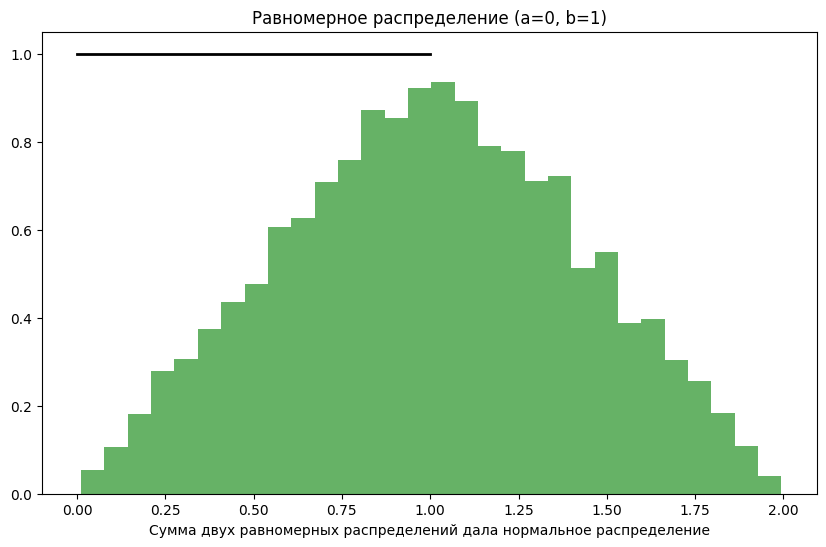

In [31]:
# Сгенерируйте 10 000 пар значений из равномерного распределения от 0 до 1. 
# Вычислите сумму каждой пары и постройте гистограмму сумм.

# Параметры
a = 0 # нижняя граница
b = 1 # верхняя граница

# Генерируем равномерно распределенные случайные величины
data_uniform_1 = uniform.rvs(loc = a, scale = b - a, size = 10000)
display(data_uniform_1)
data_uniform_2 = uniform.rvs(loc = a, scale = b - a, size = 10000)
display(data_uniform_2)
# В переменную data_uniform просуммируйте два сгенерированных набора данных
data_uniform = data_uniform_1 + data_uniform_2
display(data_uniform)


# Построение графика распределения сумм
fig = plt.figure(figsize=(10, 6))
plt.hist(data_uniform, bins = 30, density = True, alpha = 0.6, color = 'g')

# Построение графика PDF
x = np.linspace(a, b, 100)
p = uniform.pdf(x, loc = a, scale = b-a)
plt.plot(x, p, 'k', linewidth = 2)
plt.title("Равномерное распределение (a=0, b=1)")
plt.xlabel('Сумма двух равномерных распределений дала нормальное распределение')
plt.show()

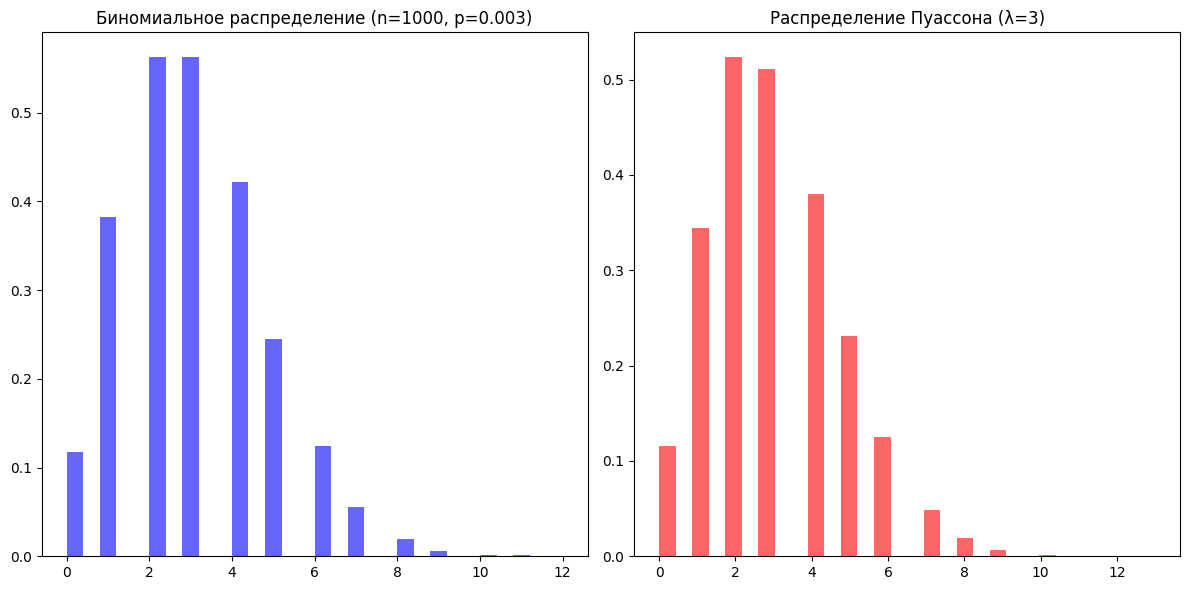

In [28]:
# При определенных условиях распределение Пуассона можно использовать в качестве приближения к биномиальному распределению:
# Число испытаний 𝑛 велико.
# Вероятность успеха 𝑝 мала.
# Произведение 𝑛𝑝 (среднее значение биномиального распределения) конечное и равно 𝜆.

# Пример:
# Если у вас есть биномиальное распределение с 𝑛=1000 и 𝑝=0.003, вы можете аппроксимировать его, 
# используя распределение Пуассона с 𝜆=𝑛𝑝=3.
from scipy.stats import binom
from scipy.stats import poisson
# Задача: сгенерировать случайные величины с биномиальным распределением, 
# сгенерировать пуассоновские распределенные случайные величины с 𝜆 = 𝑛𝑝, 
# построить графики распределений рядом друг с другом.
n = 1000 # количество испытаний
p = 0.003 # вероятность успеха
data_binom = binom.rvs(n = n, p = p, size = 10000)

mu = n * p
data_poisson = poisson.rvs(mu = mu, size = 10000)

fig = plt.figure(figsize = (12, 6))
ax1 = fig.add_subplot(121)
ax1.hist(data_binom, bins = 30, density = True, alpha = 0.6, color = 'b')
ax1.set_title('Биномиальное распределение (n=1000, p=0.003)')
ax2 = fig.add_subplot(122)
ax2.hist(data_poisson, bins = 30, density = True, alpha = 0.6, color = 'r')
ax2.set_title('Распределение Пуассона (λ=3)')
plt.tight_layout()
plt.show()